# Fase 4 · Árbol de decisión

**Universidad:** UNIFRANZ — **Materia:** Minería de Datos.

**Integrantes:** Milenka Melody Chuquimia Osco; Edson Teddy Tito Chuquimia; Carlos Daniel Valverde Mendoza; Alvaro Luis Carlos del Carpio Blanco; Marcelo Josue Escobar Chipana.

Clasificación retrospectiva de registros completos. La población corresponde a los estudiantes universitarios representados en el CSV. La etiqueta no es un diagnóstico clínico. No se demuestra causalidad, representatividad institucional ni detección anticipada. El KPI descriptivo es 24,974 % de etiquetas High; no mide calidad predictiva.


## Objetivo, hipótesis, algoritmo y límites

Hipótesis: reglas no lineales e interacciones pueden mejorar la referencia lineal. CART divide recursivamente por reducción de Gini. No presupone fronteras lineales ni requiere escalado. Profundidad, hojas, divisiones y poda controlan complejidad. Es sensible a cambios en datos y puede sobreajustar; pesos modifican proporciones e impureza.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "wrangler/03_PREPARACION_DATOS/artefactos/manifest.json").is_file())
sys.path.insert(0, str(ROOT / "wrangler/04_MODELADO"))
from eduanalytics_modelado import core
from eduanalytics_modelado.academico import texto, metricas, matrices, presentar_modelo, presentar_comparacion
import pandas as pd
from IPython.display import display
entradas = core.verificar_entradas()
print("Python:", core.versiones()["Python"], "scikit-learn:", core.versiones()["scikit-learn"])
print("CSV:", entradas["input"]["path"], "SHA-256:", entradas["input"]["sha256"])
directory = core.experimento_actual()
X, y, trace = core.cargar("train")
Xv, yv, tracev = core.cargar("validation")
print("Entrenamiento", X.shape, "Validación", Xv.shape)
assert X.index.equals(y.index)
assert not {"Student_ID", "_row_id", "Burnout_Risk_Level"} & set(X.columns)

Python: 3.10.6 scikit-learn: 1.7.2
CSV: dataset/ai_student_impact_dataset (1).csv SHA-256: 585c433cf9b447df6812c76dbb6732d2bb663689a7b595a9a4b5d777fea991d5
Entrenamiento (35000, 14) Validación (7500, 14)


## Preprocesamiento y configuración inicial

La fábrica "arbol" conserva numéricas sin escalado y aplica one-hot nominal/booleanos. max_depth 3,5,8,12,None; min_samples_leaf 1,10,50,100; min_samples_split 2,10,50; ccp_alpha 0,0.0001,0.001; pesos None/balanced. Se evalúan 16 combinaciones aleatorias reproducibles. Gini mide mezcla de etiquetas; no es una escala clínica. Cada búsqueda recibe un pipeline nuevo, sin ajustar. Balanced se calcula dentro de cada ajuste, no antes de dividir. No se usa SMOTE, imputación ni recortes. Las desconocidas generan bloques one-hot de ceros.

In [2]:
pipeline = core.crear_pipeline("arbol")
display(pipeline)
display(core.ESPACIOS["arbol"])

,steps,"[('preprocesamiento', ...), ('clasificador', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('columnas', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numericas', ...), ('categoricas', ...), ...]"
,remainder,'drop'
,sparse_threshold,0


{'clasificador__max_depth': [3, 5, 8, 12, None],
 'clasificador__min_samples_leaf': [1, 10, 50, 100],
 'clasificador__min_samples_split': [2, 10, 50],
 'clasificador__ccp_alpha': [0.0, 0.0001, 0.001],
 'clasificador__class_weight': [None, 'balanced']}

## Búsqueda, resultados y explicación

El código compartido ejecuta o verifica la búsqueda completa, guarda parámetros de todas las configuraciones y evalúa el ganador en entrenamiento y validación. Las tablas y comentarios siguientes proceden de esos cálculos. La ejecución repetida reutiliza recibos válidos, sin ejecutar nuevamente la búsqueda.

### Categorías desconocidas y controles de entrada

,variable,registros_desconocidos_validación
0,Major_Category,0
1,Year_of_Study,0
2,Primary_Use_Case,0
3,Prompt_Engineering_Skill,0
4,Institutional_Policy,0


Se observaron **0 incidencias** de categorías de validación ausentes en entrenamiento. La política `handle_unknown="ignore"` representa una desconocida mediante ceros; su prueba dirigida utiliza un caso artificial separado.

### Búsqueda y configuración seleccionada

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_clasificador__min_samples_split,param_clasificador__min_samples_leaf,param_clasificador__max_depth,param_clasificador__class_weight,param_clasificador__ccp_alpha,params,...,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score,configuration_index
0,0.149276,0.005277,0.028681,0.003762,2,10,5.0,NaN,0.0000,"{""clasificador__ccp_alpha"":0.0,""clasificador__...",...,0.005165,1,0.533399,0.531238,0.534643,0.530083,0.534436,0.532760,0.001803,6
1,0.238770,0.011084,0.028926,0.002284,2,100,12.0,NaN,0.0010,"{""clasificador__ccp_alpha"":0.001,""clasificador...",...,0.006515,2,0.524068,0.522375,0.526396,0.522037,0.529191,0.524814,0.002679,2
2,0.207420,0.006249,0.034522,0.007067,50,50,8.0,NaN,0.0010,"{""clasificador__ccp_alpha"":0.001,""clasificador...",...,0.006515,2,0.524068,0.522375,0.526396,0.522037,0.529191,0.524814,0.002679,5
3,0.234459,0.011108,0.030603,0.003894,2,100,NaN,NaN,0.0000,"{""clasificador__ccp_alpha"":0.0,""clasificador__...",...,0.006120,4,0.560631,0.557552,0.560326,0.558863,0.560142,0.559503,0.001147,7
4,0.160984,0.006366,0.025862,0.001473,10,100,5.0,balanced,0.0000,"{""clasificador__ccp_alpha"":0.0,""clasificador__...",...,0.005630,5,0.518803,0.522383,0.517377,0.516383,0.535938,0.522177,0.007175,10
5,0.230908,0.005716,0.029225,0.002943,2,50,8.0,balanced,0.0001,"{""clasificador__ccp_alpha"":0.0001,""clasificado...",...,0.009734,6,0.535758,0.539784,0.532742,0.534291,0.526446,0.533804,0.004361,12
6,0.264921,0.009470,0.029447,0.001569,2,50,12.0,NaN,0.0000,"{""clasificador__ccp_alpha"":0.0,""clasificador__...",...,0.004119,7,0.573616,0.576293,0.576860,0.574362,0.577086,0.575643,0.001395,1
7,0.117845,0.006981,0.030189,0.004819,10,10,3.0,NaN,0.0001,"{""clasificador__ccp_alpha"":0.0001,""clasificado...",...,0.009126,8,0.501786,0.499558,0.505797,0.511004,0.506504,0.504930,0.003971,9
8,0.109407,0.008433,0.027122,0.002730,2,50,3.0,NaN,0.0001,"{""clasificador__ccp_alpha"":0.0001,""clasificado...",...,0.009126,8,0.501786,0.499558,0.505797,0.511004,0.506504,0.504930,0.003971,15
9,0.109403,0.002172,0.028841,0.005634,50,50,3.0,NaN,0.0010,"{""clasificador__ccp_alpha"":0.001,""clasificador...",...,0.009126,8,0.501786,0.499558,0.505797,0.511004,0.506504,0.504930,0.003971,8


,parámetro,valor
0,clasificador__ccp_alpha,0.0
1,clasificador__class_weight,None
2,clasificador__max_depth,5
3,clasificador__min_samples_leaf,10
4,clasificador__min_samples_split,2


Se completaron **16 configuraciones** y **81 ajustes**. CV Macro F1 = **0.524107**, DE = **0.005165**. Esta media selecciona hiperparámetros; no evalúa independientemente al ganador. La desviación entre cinco pliegues no es un intervalo de confianza.

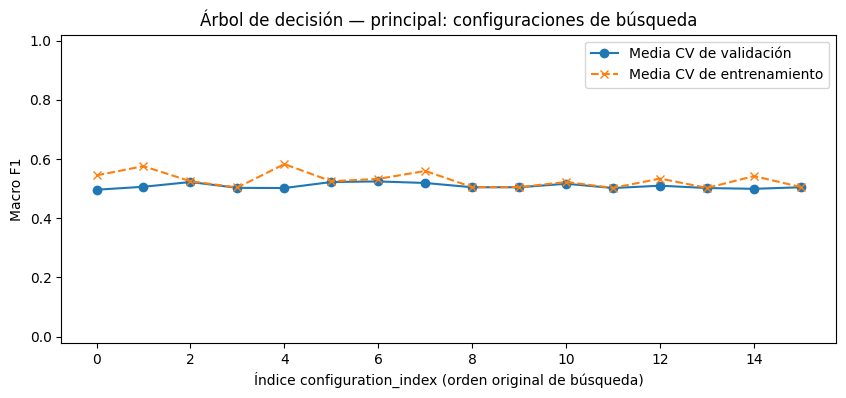

La configuración de índice **6** obtiene la mejor media CV. Las curvas muestran ajuste y validación dentro de entrenamiento; el eje no es una escala de complejidad.

### Diagnóstico en entrenamiento y comparación en validación fija

,partición,Macro F1,Accuracy
0,train,0.533612,0.526029
1,validation,0.533385,0.525733


,f1,precision,precision_undefined,recall,support
Low,0.544566,0.505763,False,0.589817,2455
Medium,0.484244,0.494094,False,0.474779,3172
High,0.571346,0.622404,False,0.52803,1873


Macro F1 = **0.533385**, Accuracy = **0.525733**. High: Precision **0.622404** y Recall **0.528030**. El soporte representa registros de cada etiqueta.

Brecha Macro F1 entrenamiento−validación = **0.000227**. Una brecha positiva señala un posible sobreajuste; una brecha pequeña tampoco garantiza generalización externa.

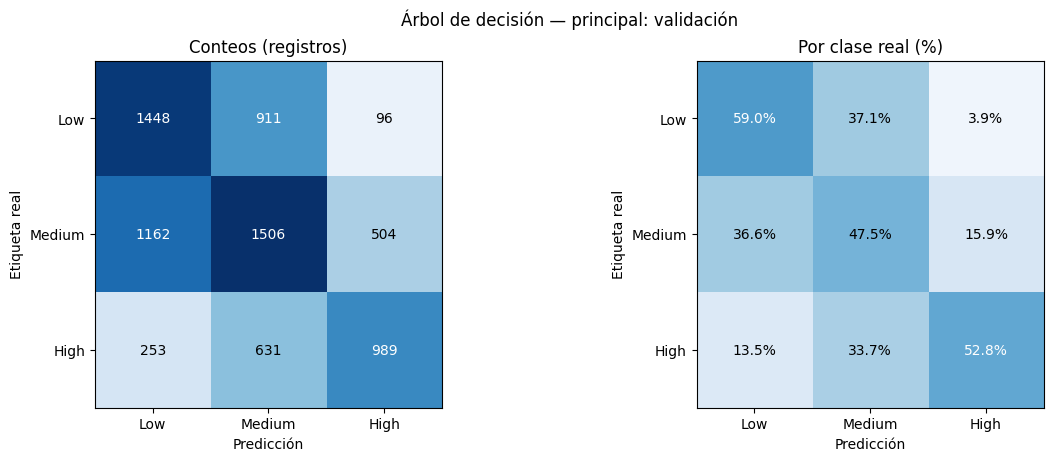

High→Low: **253**; High→Medium: **631**. Low→High: **96**; Medium→High: **504**. Los primeros son falsos negativos de High y los últimos falsos positivos. La normalización muestra la fracción de cada clase real. Un mayor Recall puede acompañarse de menor Precision; la matriz permite localizar ese compromiso.

,fits,inference_includes,search_and_refit_seconds,selected_refit_seconds,started_utc,train_inference_seconds,validation_inference_seconds
0,81,predict and predict_proba; full pipeline,27.546804,0.190246,2026-10-09T19:42:09.288591+00:00,0.071075,0.020276


Los tiempos incluyen el preprocesamiento. Son observaciones de esta ejecución y equipo, no constantes reproducibles.

### Interpretabilidad

,feature,importance
1,numericas__Weekly_GenAI_Hours,0.830710
14,categoricas__Year_of_Study_Graduate,0.071166
28,categoricas__Institutional_Policy_Strict_Ban,0.034455
13,categoricas__Year_of_Study_Freshman,0.031950
0,numericas__Pre_Semester_GPA,0.014487
6,numericas__Post_Semester_GPA,0.009946
4,numericas__Perceived_AI_Dependency,0.006060
24,categoricas__Prompt_Engineering_Skill_Beginner,0.000992
3,numericas__Traditional_Study_Hours,0.000235
5,numericas__Anxiety_Level_During_Exams,0.000000


,feature,mean,std,repeat_0,repeat_1,repeat_2,repeat_3,repeat_4
0,Major_Category,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,Tool_Diversity,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
5,Prompt_Engineering_Skill,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,Primary_Use_Case,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,Paid_Subscription,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
11,Anxiety_Level_During_Exams,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,Perceived_AI_Dependency,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,Traditional_Study_Hours,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
13,Skill_Retention_Score,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
12,Post_Semester_GPA,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


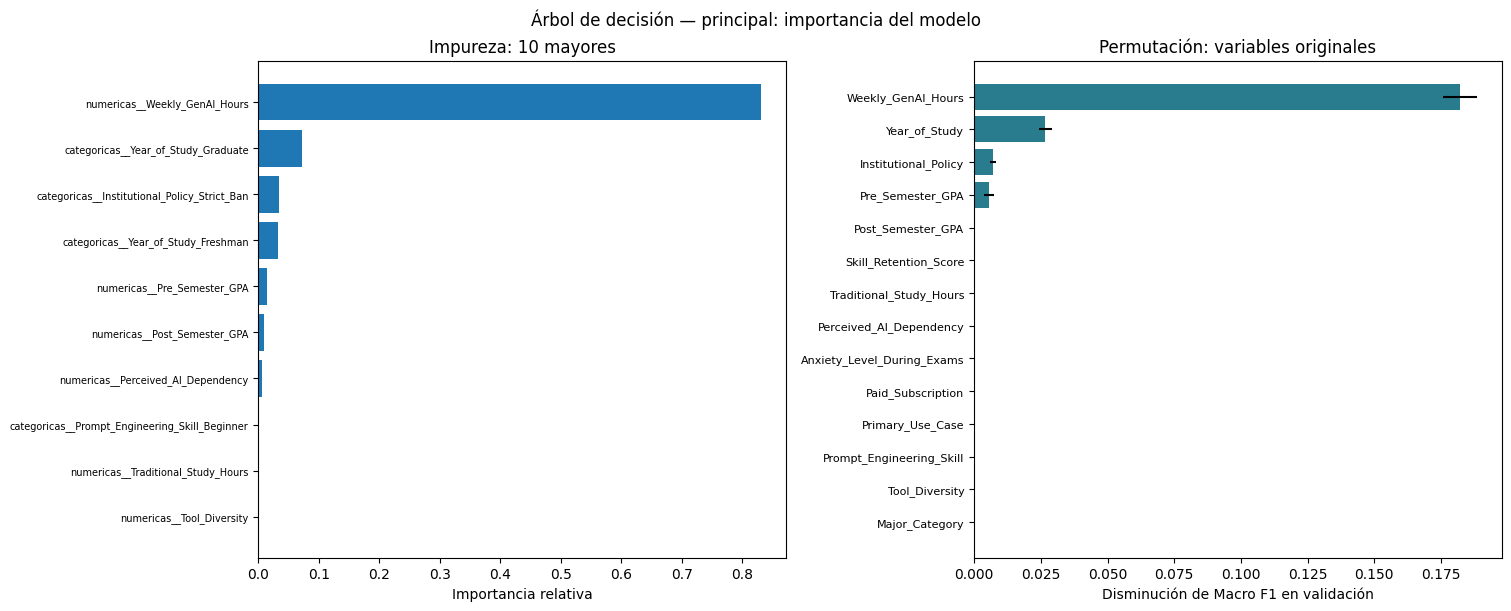

Mayor importancia por permutación: **Weekly_GenAI_Hours**, caída media **0.182192**. Las barras de error son DE de cinco permutaciones, no intervalos de confianza. Impureza puede favorecer variables con más cortes; predictores correlacionados pueden repartirse o enmascarar importancia por permutación. Estas medidas describen el modelo, no causalidad ni la fórmula de burnout.

Árbol seleccionado: profundidad **5**, **63 nodos** y **32 hojas**. La vista siguiente muestra la raíz y dos niveles descendientes; el resto se indica truncado. Las reglas completas están en `reglas.txt` y pertenecen al ganador.

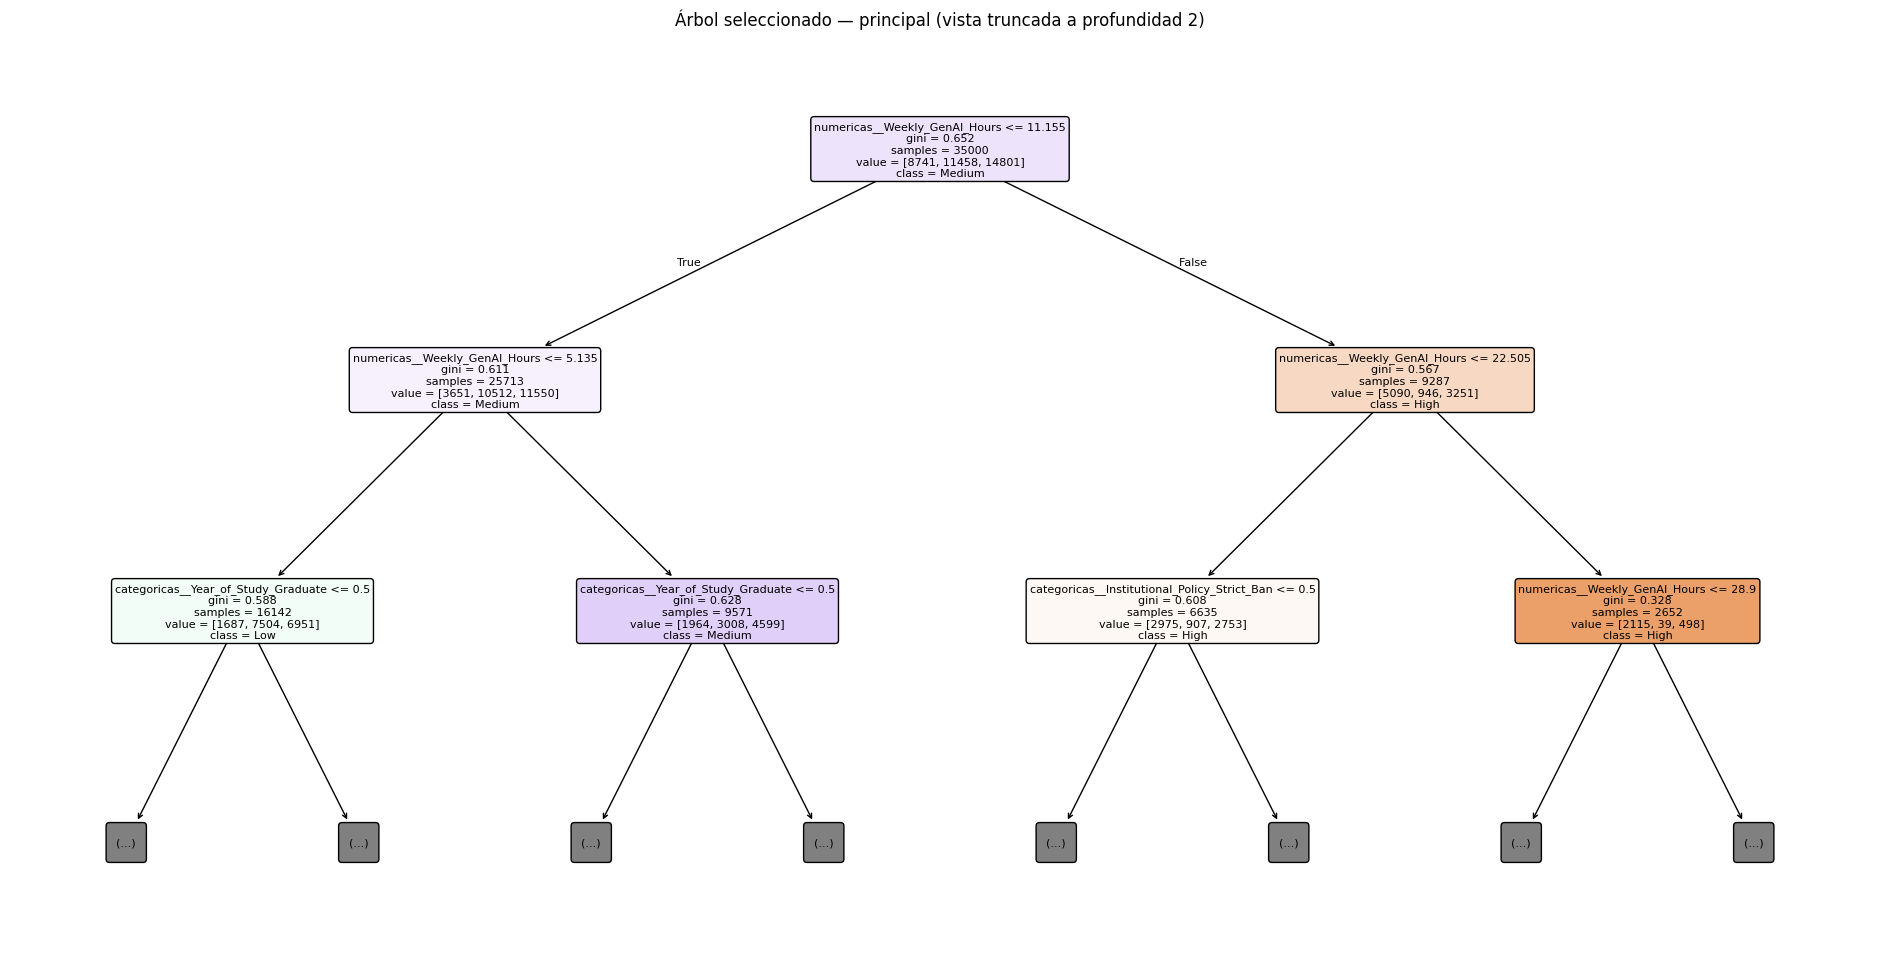

Raíz: **numericas__Weekly_GenAI_Hours ≤ 11.1550**, Gini **0.6516**, **35000 muestras**. La rama izquierda cumple el umbral; la derecha lo supera. `value` y Gini reflejan pesos si se seleccionó `balanced`; el orden real de clases es **['High', 'Low', 'Medium']**. Cada hoja predice la clase de mayor proporción ponderada.

### Conclusión del experimento
Macro F1 de validación **0.533385**; Recall de High **0.528030**. El resultado corresponde a etiquetas de registros completos de este CSV. Un desempeño alto podría reflejar reglas desconocidas de construcción de la etiqueta; no acredita detección anticipada ni utilidad clínica.

{'best_params': {'clasificador__ccp_alpha': 0.0,
  'clasificador__class_weight': None,
  'clasificador__max_depth': 5,
  'clasificador__min_samples_leaf': 10,
  'clasificador__min_samples_split': 2},
 'cv': {'configurations': 16,
  'fits': 81,
  'fold_scores': [0.5299105679181472,
   0.5307265015293666,
   0.5188174661200181,
   0.521656296978108,
   0.5194255857312101],
  'macro_f1_mean': 0.52410728365537,
  'macro_f1_std': 0.005165267741376987},
 'estimator_classes': ['High', 'Low', 'Medium'],
 'experiment_id': '3db94eb69df3c875',
 'interpretation': {'depth': 5,
  'estimator_classes': ['High', 'Low', 'Medium'],
  'feature_names': ['numericas__Pre_Semester_GPA',
   'numericas__Weekly_GenAI_Hours',
   'numericas__Tool_Diversity',
   'numericas__Traditional_Study_Hours',
   'numericas__Perceived_AI_Dependency',
   'numericas__Anxiety_Level_During_Exams',
   'numericas__Post_Semester_GPA',
   'numericas__Skill_Retention_Score',
   'categoricas__Major_Category_Arts',
   'categoricas__Majo

In [3]:
resultado = core.entrenar("arbol", directory=directory)
presentar_modelo("arbol", directory=directory)

## Referencia y cierre

[API scikit-learn 1.7.2](https://scikit-learn.org/1.7/modules/generated/sklearn.tree.DecisionTreeClassifier.html). La comparación definitiva se realiza en el notebook 05 y la prueba en el 06. Una métrica alta describe concordancia con etiquetas disponibles; no descubre su fórmula original ni acredita un resultado de negocio.